# 例9.1程序

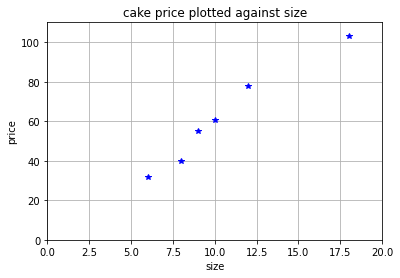

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
#输入并查看数据
cake = pd.read_csv("E:dangao.csv")
cake
#定义散点图中元素
def runplt():
    plt.figure()
    plt.title("cake price plotted against size")
    plt.xlabel('size')
    plt.ylabel('price')
    plt.grid(True)
    plt.xlim(0, 20)
    plt.ylim(0, 110)
    return plt
#给定x，y并画图
x = cake.loc[:,'size'].values
y = cake.loc[:,'price'].values
plt = runplt()
plt.plot(x, y, 'b*')
plt.show()


In [2]:
model = LinearRegression()  #创建模型
X = x.reshape((-1,1))
Y = y
model.fit(X, Y)  #拟合
display(model.intercept_) #截距
display(model.coef_) #回归系数


-2.513333333333321

array([6.08857143])

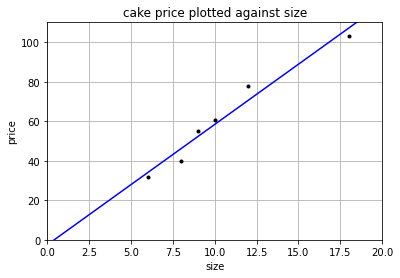

均方误差为: 21.09


In [3]:
X2 = [[0],[16],[20], [25]] # 取预测值
Y2 = model.predict(X2)  # 进行预测
plt = runplt()
plt.plot(x, y, 'k.')
plt.plot(X2, Y2, 'b-')  # 画出拟合曲线
plt.show()
###4
print("均方误差为: %.2f" % np.mean((model.predict(X)-y) ** 2))
###均方误差为：21.09


# 例9.2程序

In [5]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
data = pd.read_csv("E:MDG.csv", index_col='id') #加载数据
data
#设置训练集和测试集
X = data.iloc[:-6, :2].values
Y = data.iloc[:-6, 2].values.reshape((-1, 1))
X_test = data.iloc[-6:, :2].values
Y_test = data.iloc[-6:, 2].values.reshape((-1, 1))
#线性拟合
model = LinearRegression()
model.fit(X, Y)
#输出截距项和系数
display(model.intercept_)
display(model.coef_)
#预测
predictions = model.predict(X_test)
for i, prediction in enumerate(predictions):
    print('Predicted: %s, Target: %s' % (prediction, Y_test[i]))
#模型评估
print('R-squared: %.2f' % model.score(X_test, Y_test))

array([-16.25297457])

array([[2.30530893, 3.66470375]])

Predicted: [37.06365888], Target: [38.]
Predicted: [50.15633871], Target: [53.]
Predicted: [66.91372229], Target: [78.]
Predicted: [80.00640213], Target: [85.]
Predicted: [81.5725373], Target: [99.]
Predicted: [100.42848946], Target: [108.]
R-squared: 0.86


# 例9.3程序

岭回归系数： [-9.45649988e-02  4.31779738e-02  3.09287015e-02  1.03870830e+00
 -8.24044635e+00  4.41307732e+00 -6.73616246e-03 -1.26756721e+00
  2.62435243e-01 -1.29831475e-02 -8.61829726e-01  6.97278070e-03
 -5.58516946e-01]
岭回归截距： 27.3459664055989
LASSO回归系数： [-0.05126709  0.03901822 -0.          0.         -0.          1.6908947
  0.01940443 -0.61846349  0.20683394 -0.01320551 -0.69021252  0.00510198
 -0.75151284]
LASSO回归截距： 36.515254739207926
0.6775930475897152
25.451526435951994
0.6554460628881653
27.19985897777263


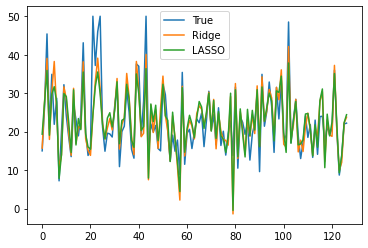

In [6]:
from sklearn.datasets import load_boston #数据集
from sklearn.model_selection import train_test_split #划分训练集测试集
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error,r2_score #模型评价指标
import matplotlib.pyplot as plt
# 加载数据
boston_sample = load_boston()
x_train, x_test, y_train, y_test = train_test_split( boston_sample.data, boston_sample.target,test_size=0.25,random_state=123)
#岭回归
ridge = Ridge()
ridge.fit(x_train, y_train)
print('岭回归系数：', ridge.coef_)
print('岭回归截距：', ridge.intercept_)
y_ridge_pre = ridge.predict(x_test)
#Lasso
lasso = Lasso()
lasso.fit(x_train, y_train)
print('LASSO回归系数：', lasso.coef_)
print('LASSO回归截距：', lasso.intercept_)
y_lasso_pre = lasso.predict(x_test)
print(r2_score(y_test, y_ridge_pre)) #岭回归的r2
print(mean_squared_error(y_test,y_ridge_pre)) #岭回归的均方误差
print(r2_score(y_test, y_lasso_pre)) #LASSO回归的r2
print(mean_squared_error(y_test,y_lasso_pre)) #LASSO回归的均方误差
#>岭回归的r2为： 0.6775930475897152
#>岭回归的均方误差为： 25.451526435951994
#>LASSO回归的r2为： 0.6554460628881653
#>LASSO回归的均方误差为： 27.19985897777263
#画出对比图
plt.plot(y_test, label='True')
plt.plot(y_ridge_pre, label='Ridge')
plt.plot(y_lasso_pre, label='LASSO')
plt.legend()
plt.show()

# 例9.4程序

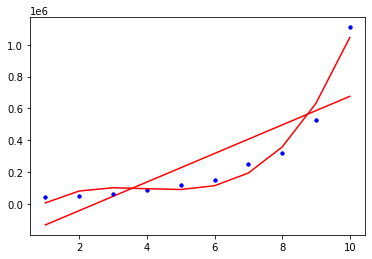

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
data = np.genfromtxt('E:yangben.csv', delimiter=',')# 加载数据
x_data = data[1:, 1]
y_data = data[1:, 2]
x_2data = x_data[:, np.newaxis]# 将一维数据增加维度从而转为二维数据
y_2data = data[1:, 2, np.newaxis]
model = LinearRegression()# 训练一元线性模型
model.fit(x_2data, y_2data)
plt.plot(x_2data, y_2data, 'b.')
plt.plot(x_2data, model.predict(x_2data), 'r')
poly_reg = PolynomialFeatures(degree=3)# 定义多项式回归
x_ploy = poly_reg.fit_transform(x_2data)  # # 特征处理；实质：把非线性的模型转为线性模型
lin_reg_model = LinearRegression()# 训练线性模型（由非线性模型转换而来）
lin_reg_model.fit(x_ploy, y_2data)
plt.plot(x_2data, y_2data, 'b.')
plt.plot(x_2data, lin_reg_model.predict(x_ploy), 'r')
plt.show()
